##**PROJECT TITLE**
# "Bank Marketing Campaign Analysis & Term Deposit Prediction”

# **Objective(Problem statment)**

1. To analyze customer demographics and financial characteristics to understand the profile of customers targeted by the bank.
2. To evaluate the effectiveness of marketing campaigns based on factors such as contact method, month, campaign duration, and number of contacts.
3. To identify the key factors influencing term-deposit subscriptions and determine which customer characteristics are associated with higher conversion rates.
4. To segment customers based on their characteristics and campaign responses to identify high-potential customer groups.
5. To develop a predictive model that can identify customers who are more likely to subscribe to a term deposit, helping the bank improve its marketing strategy

# **Outcome**

The project can focus on Predicting whether a bank customer will subscribe to a term deposit based on their demographic, financial, and campaign-related characteristics.

# **Domain**
# Banking campaign analysis

#**Dataset Information**

**Source:** UCI ML Repository  <font color="blue"><u> **https://archive.ics.uci.uci.edu/dataset/222/bank+marketing**</font></u>

**Year / Timeline:** Data collected during 2014 to 2019

**Dataset Column/features Description:**

*   **Age** -Customer Age
*   **job** - Type of occupation/job (Categorical)
*   **marital** - Marital status of the customer (Categorical)
*   **education** - Education level (Categorical)
*   **default** - Whether the customer has credit in default (Categorical)
*   **balance** - Average yearly balance in the customer's bank account (Numerical)
*   **housing** - Whether the customer has a housing loan (Categorical)
*   **loan** - Whether the customer has a personal loan (Categorical)
*   **contact** - Communication method used to contact the customer (Categorical)
*   **day** - Day of the month when the customer was last contacted (Numerical)
*   **month** - Month when the customer was last contacted (Categorical)
*   **duration** - Duration of the last contact, in seconds (Numerical)
*   **campaign** - Number of contacts made during the current campaign (Numerical)
*   **pdays** - Number of days since the customer was last contacted in a previous campaign (Numerical)
*   **previous** - Number of contacts made before the current campaign (Numerical)
*   **poutcome** - Outcome of the previous marketing campaign (Categorical)
*   **y** - Whether the customer subscribed to a term deposit (yes/no)

# Stages for DA Project

## Stage 1 – Problem Definition and Dataset Selection



Stage 1 – Problem Definition and Dataset Selection
1. Business Problem
Banks conduct marketing campaigns to encourage customers to subscribe to term deposits. However, contacting every customer can be time-consuming and costly.
Business problem:
Identify the customer characteristics and campaign factors that influence term-deposit subscriptions and use the available data to understand which customers are more likely to subscribe.
2. Expected Outcome
Analyze customer and campaign data to identify patterns associated with term-deposit subscriptions and develop insights that can help the bank improve the effectiveness of its marketing campaigns.
Target variable: y
yes → Customer subscribed to a term deposit
no → Customer did not subscribe


# **Inital EDA**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1) Load the Dataset
url = "https://raw.githubusercontent.com/Keerthanadevi-R15/-Bank-Marketing-Campaign-Analysis-Term-Deposit-Prediction-/main/raw%20dataset%20for%20bank.csv"
df = pd.read_csv(url, sep=';')

In [ ]:
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [ ]:
# dataset shape

df.shape

(45211, 17)

In [ ]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
# Column Names

df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [ ]:
#Statistical Summary

df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## Stage 2 – Data Cleaning and Pre-processing


In [ ]:
# Check Missing Values

df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
# Duplicate Record Check

df.duplicated().sum()

np.int64(0)

In [ ]:
#age group

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 55, 100],
    labels=["18-25", "26-35", "36-45", "46-55", "56+"]
)

In [ ]:
df[["age","age_group"]].head(10)

,age,age_group
0,58,56+
1,44,36-45
2,33,26-35
3,47,46-55
4,33,26-35
5,35,26-35
6,28,26-35
7,42,36-45
8,58,56+
9,43,36-45


In [ ]:
#Balance category

df["balance_category"] = pd.cut(
    df["balance"],
    bins=[-float("inf"), 0, 1000, 5000, float("inf")],
    labels=["Negative", "Low", "Medium", "High"]
)

In [ ]:
#campaign contact category

df["campaign_category"] = pd.cut(
    df["campaign"],
    bins=[0, 1, 3, 5, float("inf")],
    labels=["1", "2-3", "4-5", "6+"]
)

In [ ]:
#contact duration in minutes

df["duration_minutes"] = df["duration"] / 60

In [ ]:
#check the new columns

df[[
    "age",
    "age_group",
    "balance",
    "balance_category",
    "campaign",
    "campaign_category",
    "duration",
    "duration_minutes",
]].head()

,age,age_group,balance,balance_category,campaign,campaign_category,duration,duration_minutes
0,58,56+,2143,Medium,1,1,261,4.350000
1,44,36-45,29,Low,1,1,151,2.516667
2,33,26-35,2,Low,1,1,76,1.266667
3,47,46-55,1506,Medium,1,1,92,1.533333
4,33,26-35,1,Low,1,1,198,3.300000


**Term deposit subscription**

What it shows: Number of customers who subscribed (yes) and did not subscribe (no).

Why it is used: To understand the distribution of the target variable.

**Type: Univariate — only y is analyzed.**

Interpretation: The number of customers who did not subscribe is much higher than those who subscribed.

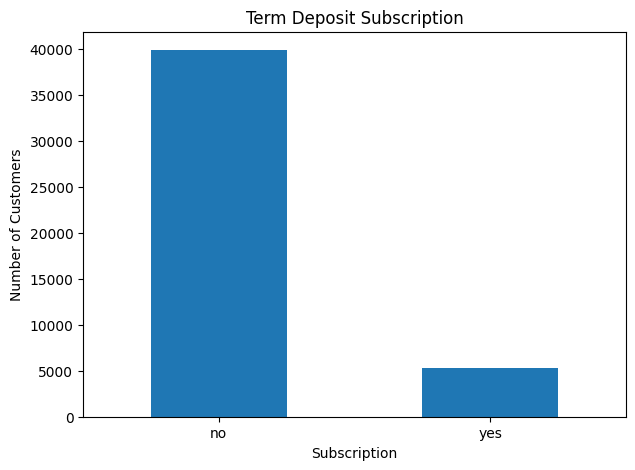

In [ ]:

plt.figure(figsize=(7,5))

df["y"].value_counts().plot(kind="bar")

plt.title("Term Deposit Subscription")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

**Customer Age Distribution**

What it shows: Distribution of customers across different ages.

Why it is used: To understand the age profile of the bank's customers.

**Type: Univariate**

Interpretation: It shows which age ranges contain the largest concentration of customers and whether the distribution is spread across younger or older customers

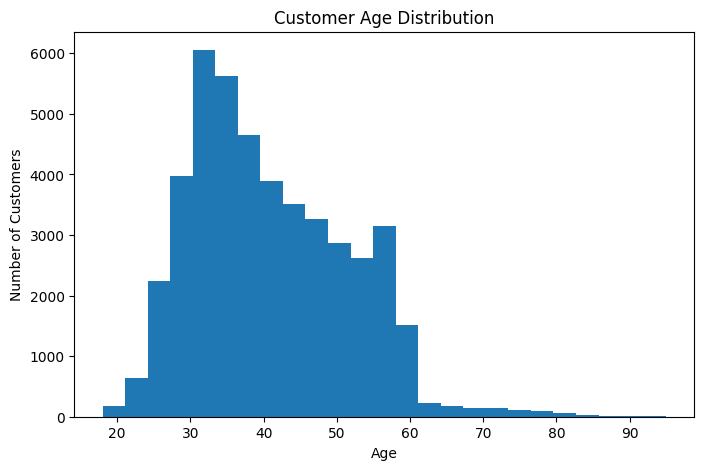

In [ ]:

plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=25)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

 **Customers by Job**

What it shows: Number of customers in each occupation.

Why it is used: To understand the occupational composition of the customer base.

**Type: Univariate**

Interpretation: Some occupations have considerably more customers than others, which helps identify the major customer segments.

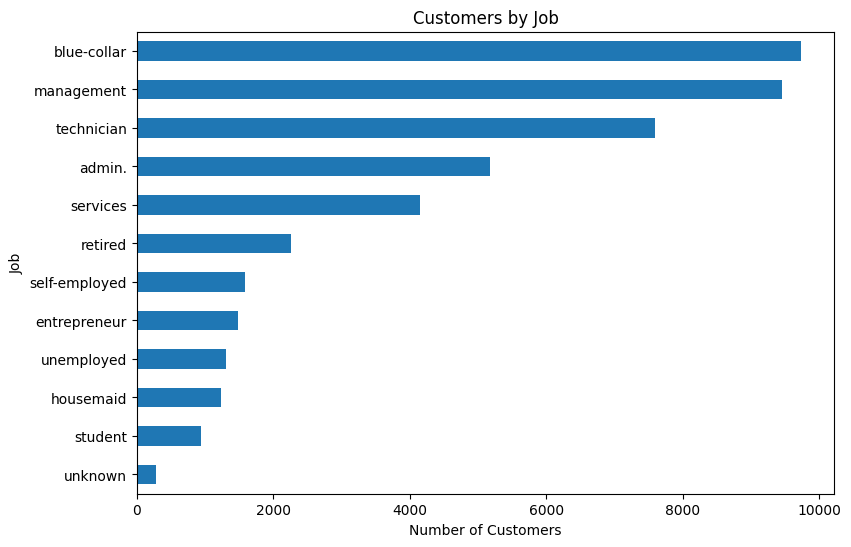

In [ ]:

plt.figure(figsize=(9,6))

df["job"].value_counts().sort_values().plot(kind="barh")

plt.title("Customers by Job")
plt.xlabel("Number of Customers")
plt.ylabel("Job")

plt.show()

**Education Level Distribution**

What it shows: Number of customers in each education category.

Why it is used: To understand the education profile of customers.

**Type: Univariate**

Interpretation: The chart shows which education categories are most common among customers

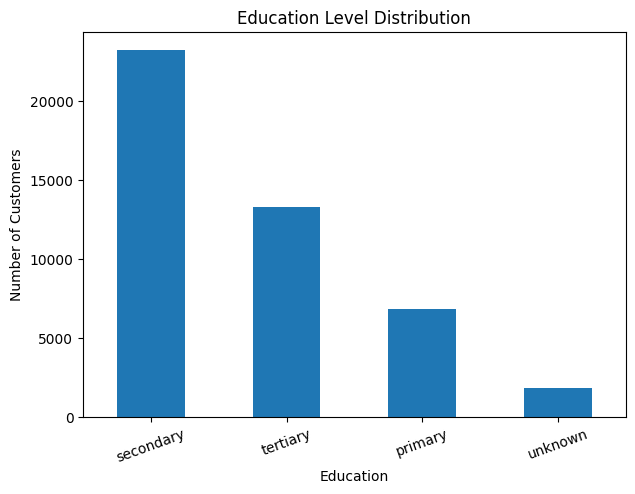

In [ ]:

plt.figure(figsize=(7,5))

df["education"].value_counts().plot(kind="bar")

plt.title("Education Level Distribution")
plt.xlabel("Education")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

**Marital Status Distribution**

What it shows: Number of married, single, and divorced customers.

Why it is used: To understand the demographic structure of the customer base.

**Type: Univariate**

Interpretation: It identifies the dominant marital-status group among customers.

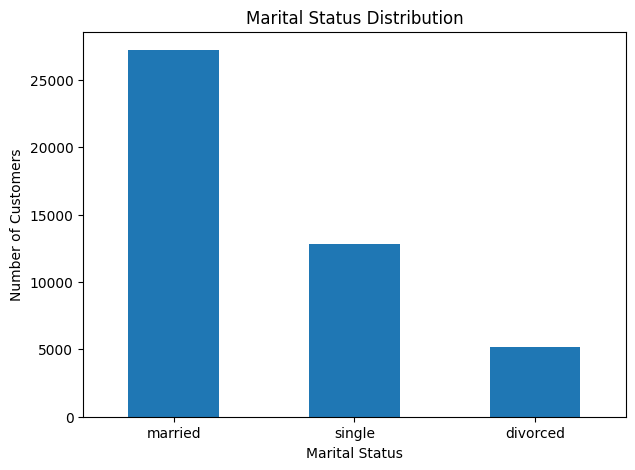

In [ ]:

plt.figure(figsize=(7,5))

df["marital"].value_counts().plot(kind="bar")

plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

**Account Balance Distribution**

What it shows: Distribution of customers' account balances.

Why it is used: To understand the financial distribution of customers and identify skewness or extreme values.

**Type: Univariate**

Interpretation: Account balances are typically spread unevenly, with some customers having substantially higher balances than others.

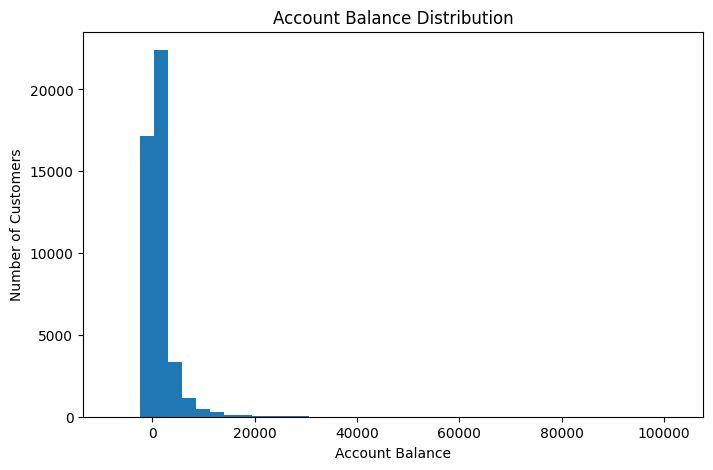

In [ ]:

plt.figure(figsize=(8,5))

plt.hist(df["balance"], bins=40)

plt.title("Account Balance Distribution")
plt.xlabel("Account Balance")
plt.ylabel("Number of Customers")

plt.show()

**Subscription by Housing Loan**

What it shows: Subscription behavior for customers with and without housing loans.

Why it is used: To investigate whether housing-loan status is associated with subscription behavior.

**Type: Bivariate**

Variables: housing + y

Interpretation: The subscription percentages differ between customers with and without housing loans. This indicates an association between housing-loan status and subscription in this dataset.

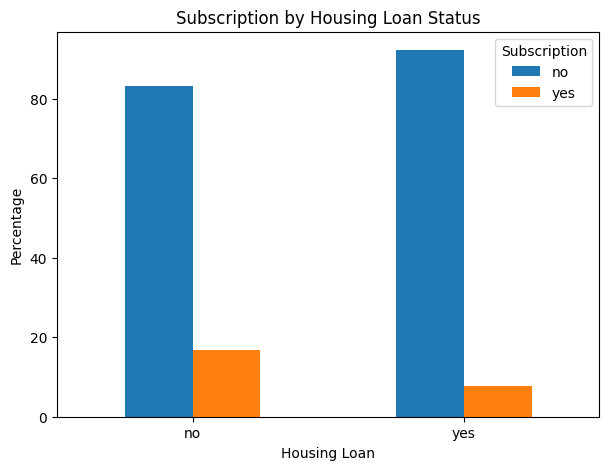

In [ ]:

housing = pd.crosstab(
    df["housing"],
    df["y"],
    normalize="index"
) * 100

housing.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Subscription by Housing Loan Status")
plt.xlabel("Housing Loan")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Subscription")

plt.show()

**Subscription by Personal Loan**

What it shows: Subscription rates for customers with and without personal loans.

Why it is used: To investigate whether personal-loan status is associated with subscription.

**Type: Bivariate**

Variables: loan + y

Interpretation: The subscription rates vary between the two personal-loan groups, showing an association worth considering in customer analysis.

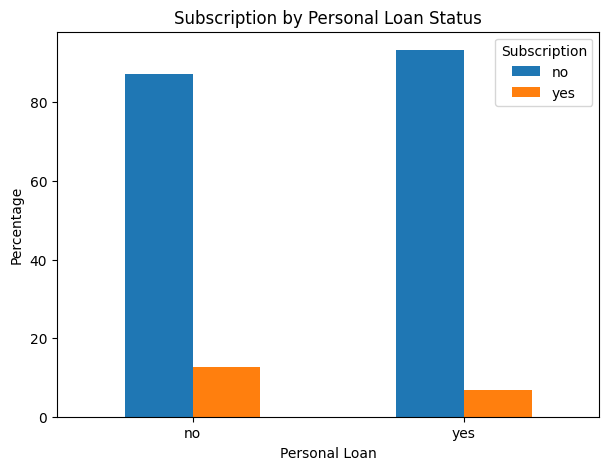

In [ ]:
loan = pd.crosstab(
    df["loan"],
    df["y"],
    normalize="index"
) * 100

loan.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Subscription by Personal Loan Status")
plt.xlabel("Personal Loan")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Subscription")

plt.show()

**Subscription Rate by Job**

What it shows: Subscription rate for each occupation.

Why it is used: Customer occupation may be useful for identifying differences in campaign response.

**Type: Bivariate**

Variables: job + y

Interpretation: Subscription rates differ across occupations. Some occupational groups show higher observed subscription rates than others.

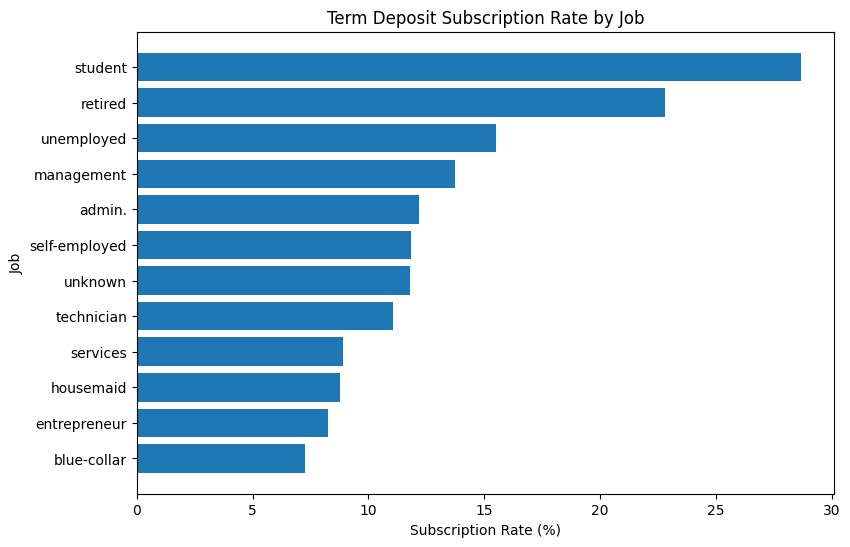

In [ ]:

job_rate = pd.crosstab(
    df["job"],
    df["y"],
    normalize="index"
)["yes"] * 100

job_rate = job_rate.sort_values()

plt.figure(figsize=(9,6))

plt.barh(job_rate.index, job_rate.values)

plt.title("Term Deposit Subscription Rate by Job")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job")

plt.show()

**Subscription Rate by Education**

What it shows: Percentage of customers subscribing within each education group.

Why it is used: To investigate whether subscription behavior differs across education levels.

**Type: Bivariate**

Variables: education + y

Interpretation: The observed subscription rate varies among education groups.

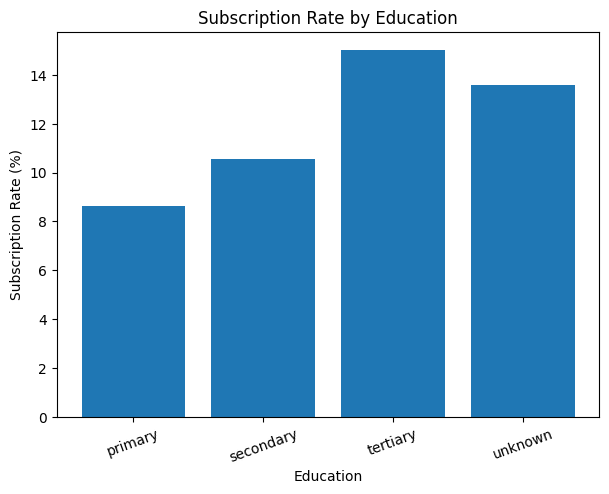

In [ ]:

education_rate = pd.crosstab(
    df["education"],
    df["y"],
    normalize="index"
)["yes"] * 100

plt.figure(figsize=(7,5))

plt.bar(
    education_rate.index,
    education_rate.values
)

plt.title("Subscription Rate by Education")
plt.xlabel("Education")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=20)

plt.show()

**Number of Campaign Contacts**

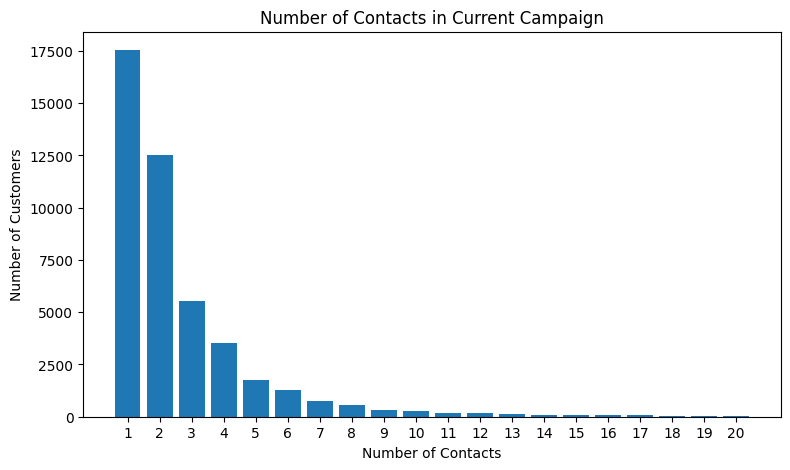

In [ ]:

campaign_counts = df["campaign"].value_counts().sort_index()

# Display the most common range clearly
campaign_counts = campaign_counts[
    campaign_counts.index <= 20
]

plt.figure(figsize=(9,5))

plt.bar(
    campaign_counts.index.astype(str),
    campaign_counts.values
)

plt.title("Number of Contacts in Current Campaign")
plt.xlabel("Number of Contacts")
plt.ylabel("Number of Customers")

plt.show()

**Last Contact Duration**

What it shows: Distribution of the duration of the last customer contact.

Why it is used: To understand the typical call duration and identify unusually short or long calls.

**Type: Univariate**

Variable: duration

Interpretation: Call duration is generally unevenly distributed, with many shorter calls and fewer very long calls.

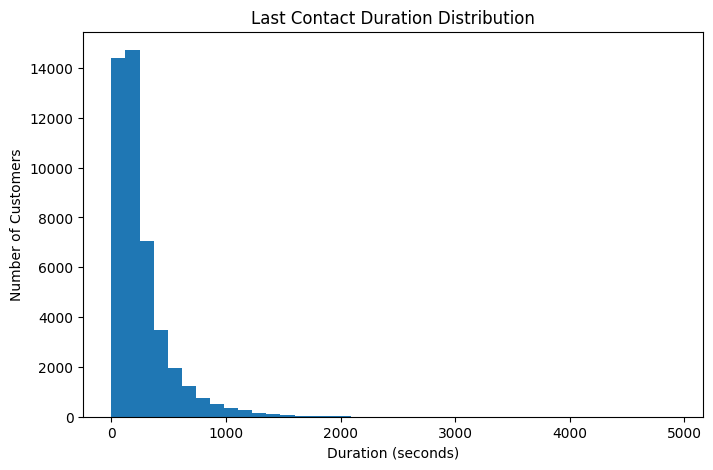

In [ ]:

plt.figure(figsize=(8,5))

plt.hist(
    df["duration"],
    bins=40
)

plt.title("Last Contact Duration Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Customers")

plt.show()

**Previous Campaign Outcome**

What it shows: Subscription rate according to the outcome of the previous campaign.

Why it is used: Previous campaign experience may be useful for understanding current customer response.

**Type: Bivariate**

Variables: poutcome + y

Interpretation: Customers with different previous campaign outcomes have different observed subscription rates.

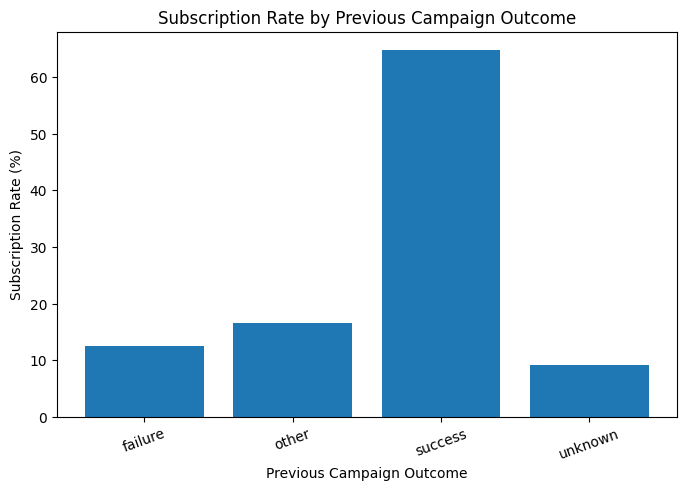

In [ ]:

previous_outcome = pd.crosstab(
    df["poutcome"],
    df["y"],
    normalize="index"
)["yes"] * 100

plt.figure(figsize=(8,5))

plt.bar(
    previous_outcome.index,
    previous_outcome.values
)

plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=20)

plt.show()

**Subscription Rate by Contact Month**

What it shows: Subscription rate across contact months.

Why it is used: To identify whether campaign response varies across different months.

**Type: Bivariate**

Variables: month + y

Interpretation: Subscription rates vary across months, suggesting that the timing of customer contact is associated with different response rates in this dataset.

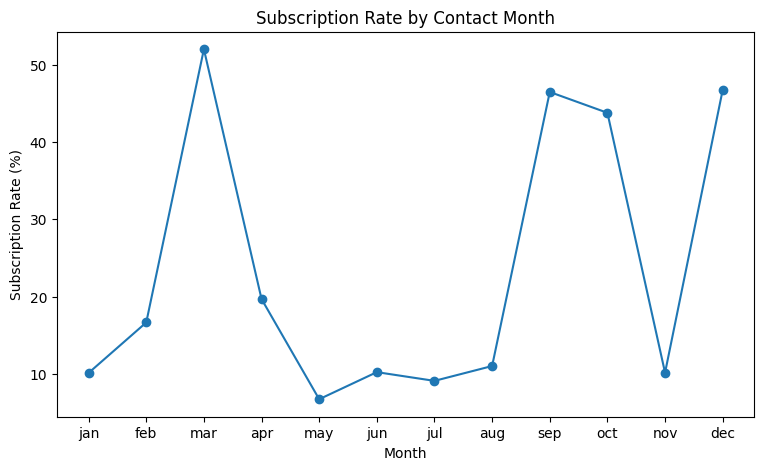

In [ ]:

month_order = [
    "jan", "feb", "mar", "apr",
    "may", "jun", "jul", "aug",
    "sep", "oct", "nov", "dec"
]

month_rate = pd.crosstab(
    df["month"],
    df["y"],
    normalize="index"
)["yes"] * 100

month_rate = month_rate.reindex(
    [m for m in month_order if m in month_rate.index]
)

plt.figure(figsize=(9,5))

plt.plot(
    month_rate.index,
    month_rate.values,
    marker="o"
)

plt.title("Subscription Rate by Contact Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")

plt.show()

**Age vs Account Balance**

X-axis: age

Y-axis: balance

Why it is used: To examine whether age and account balance have a relationship.

**Type: Bivariate**

Interpretation: The scatter plot helps determine whether there is an obvious linear relationship, clustering, or extreme observations between age and balance.

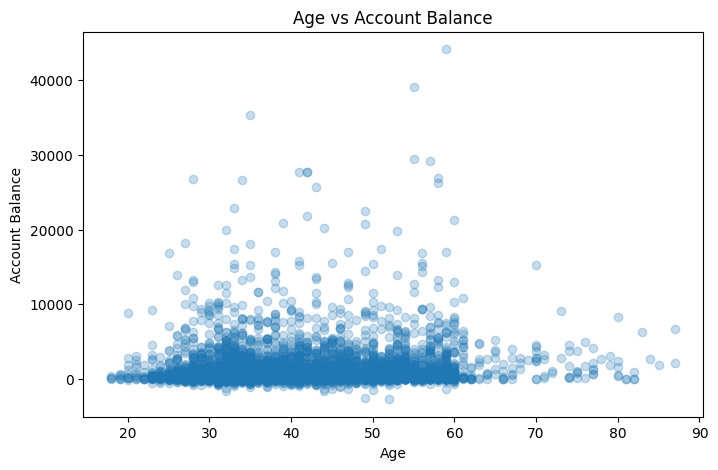

In [ ]:

sample_df = df.sample(
    n=5000,
    random_state=42
)

plt.figure(figsize=(8,5))

plt.scatter(
    sample_df["age"],
    sample_df["balance"],
    alpha=0.25
)

plt.title("Age vs Account Balance")
plt.xlabel("Age")
plt.ylabel("Account Balance")

plt.show()

# **Correlation analysis**

Variables can include:
age, balance, day, duration, campaign, pdays, previous, subscription

**Type: Multivariate**

Why it is used: To examine the strength and direction of relationships among several numerical variables simultaneously.

Interpretation: Values closer to +1 indicate a stronger positive linear relationship, values closer to -1 indicate a stronger negative linear relationship, and values near 0 indicate a weak linear relationship.

In [ ]:
df['y_numeric'] = df['y'].map({'no': 0, 'yes': 1})

numeric_columns = [
    "age",
    "balance",
    "day",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "y_numeric"
]

correlation_matrix = df[numeric_columns].corr()

print(correlation_matrix)

                age   balance       day  duration  campaign     pdays  \
age        1.000000  0.097783 -0.009120 -0.004648  0.004760 -0.023758   
balance    0.097783  1.000000  0.004503  0.021560 -0.014578  0.003435   
day       -0.009120  0.004503  1.000000 -0.030206  0.162490 -0.093044   
duration  -0.004648  0.021560 -0.030206  1.000000 -0.084570 -0.001565   
campaign   0.004760 -0.014578  0.162490 -0.084570  1.000000 -0.088628   
pdays     -0.023758  0.003435 -0.093044 -0.001565 -0.088628  1.000000   
previous   0.001288  0.016674 -0.051710  0.001203 -0.032855  0.454820   
y_numeric  0.025155  0.052838 -0.028348  0.394521 -0.073172  0.103621   

           previous  y_numeric  
age        0.001288   0.025155  
balance    0.016674   0.052838  
day       -0.051710  -0.028348  
duration   0.001203   0.394521  
campaign  -0.032855  -0.073172  
pdays      0.454820   0.103621  
previous   1.000000   0.093236  
y_numeric  0.093236   1.000000  


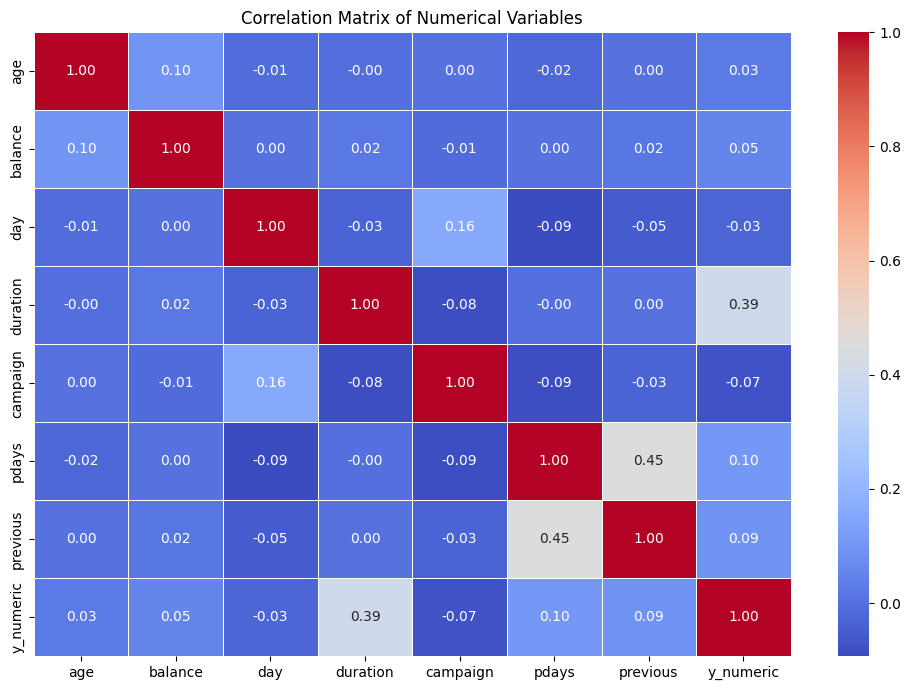

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

**MULTIVARIATE ANALYSIS**

Job + Education + Subscription Rate

Variables: job, education, y

Power BI visual: Clustered bar chart

Fields:


1.   Y-axis: job

2.   X-axis: Subscription Rate

3.   Legend: education



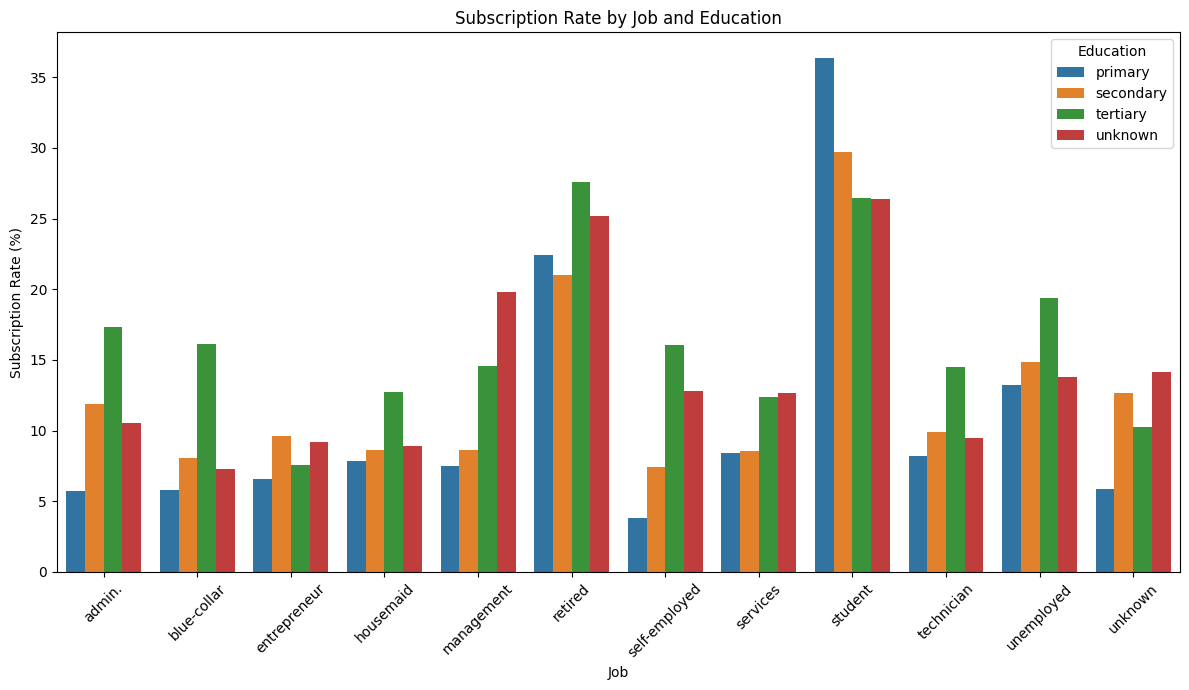

In [ ]:
job_education = (
    df.groupby(["job", "education"])["y_numeric"]
      .mean()
      .mul(100)
      .reset_index()
)

job_education.columns = [
    "job",
    "education",
    "subscription_rate"
]

plt.figure(figsize=(12, 7))

sns.barplot(
    data=job_education,
    x="job",
    y="subscription_rate",
    hue="education"
)

plt.title("Subscription Rate by Job and Education")
plt.xlabel("Job")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=45)
plt.legend(title="Education")
plt.tight_layout()
plt.show()

# **Interpretation:**

This chart compares job and education together against subscription rate. It helps identify customer segments where particular combinations of occupation and education have relatively higher subscription rates.

Type: Multivariate — 3 variables.

**MULTIVARIATE ANALYSIS **



Age + Balance + Subscription


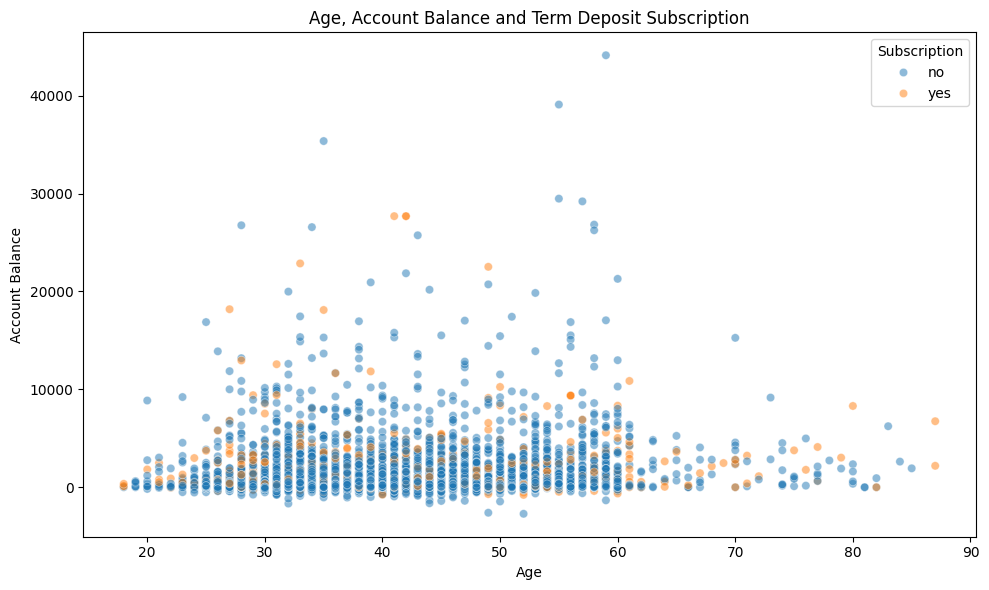

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df.sample(5000, random_state=42),
    x="age",
    y="balance",
    hue="y",
    alpha=0.5
)

plt.title("Age, Account Balance and Term Deposit Subscription")
plt.xlabel("Age")
plt.ylabel("Account Balance")
plt.legend(title="Subscription")
plt.tight_layout()
plt.show()

**INTERPRETATION:**

This visual examines the relationship between age and account balance, while using subscription status as an additional variable.

**Type: Multivariate — 3 variables.**

## **KEY INSIGHTS**

1. Overall subscription:
The majority of customers did not subscribe to the term deposit. Only about
7% of customers subscribed, indicating that the campaign conversion rate was relatively low.

2. Previous campaign outcome:
Customers who had a successful outcome in the previous campaign are more likely to subscribe, suggesting that previous campaign history can be useful for identifying potential customers.

3. Call duration:
Call duration is an important campaign-related variable. Longer conversations tend to be associated with a higher likelihood of subscription, although this relationship should not be interpreted as causation.

4. Customer characteristics:
Subscription rates vary across job and education categories, indicating that customer characteristics can help identify segments with relatively higher response rates.

5. Campaign timing:
Subscription rates vary across contact months, suggesting that campaign timing may influence customer response.

## **RECOMMENDATIONS**

1. Focus marketing efforts on customer segments with higher historical subscription rates.
2. Prioritize customers who responded positively in previous campaigns.
3. Analyze successful calls to understand what makes longer conversations effective.
4. Optimize campaign timing based on months with stronger subscription rates.
5. Avoid repeatedly contacting customers without considering previous campaign response.

## **Conclusion**

The Bank Marketing Campaign Analysis provided valuable insights into customer behavior and campaign performance. Using Python and Power BI, the dataset was cleaned, analyzed, and visualized to identify patterns related to term-deposit subscriptions.

The analysis showed that only 11.7% of customers subscribed, highlighting an opportunity to improve campaign effectiveness. Customer characteristics, previous campaign outcomes, contact timing, and campaign interactions showed differences in subscription rates across customer groups.

The Power BI dashboard brings these findings together through KPIs, interactive charts, and slicers, making it easier to explore customer segments and campaign performance.

Overall, this project demonstrates how data analysis and visualization can transform raw banking data into meaningful business insights and support data-driven marketing decisions.